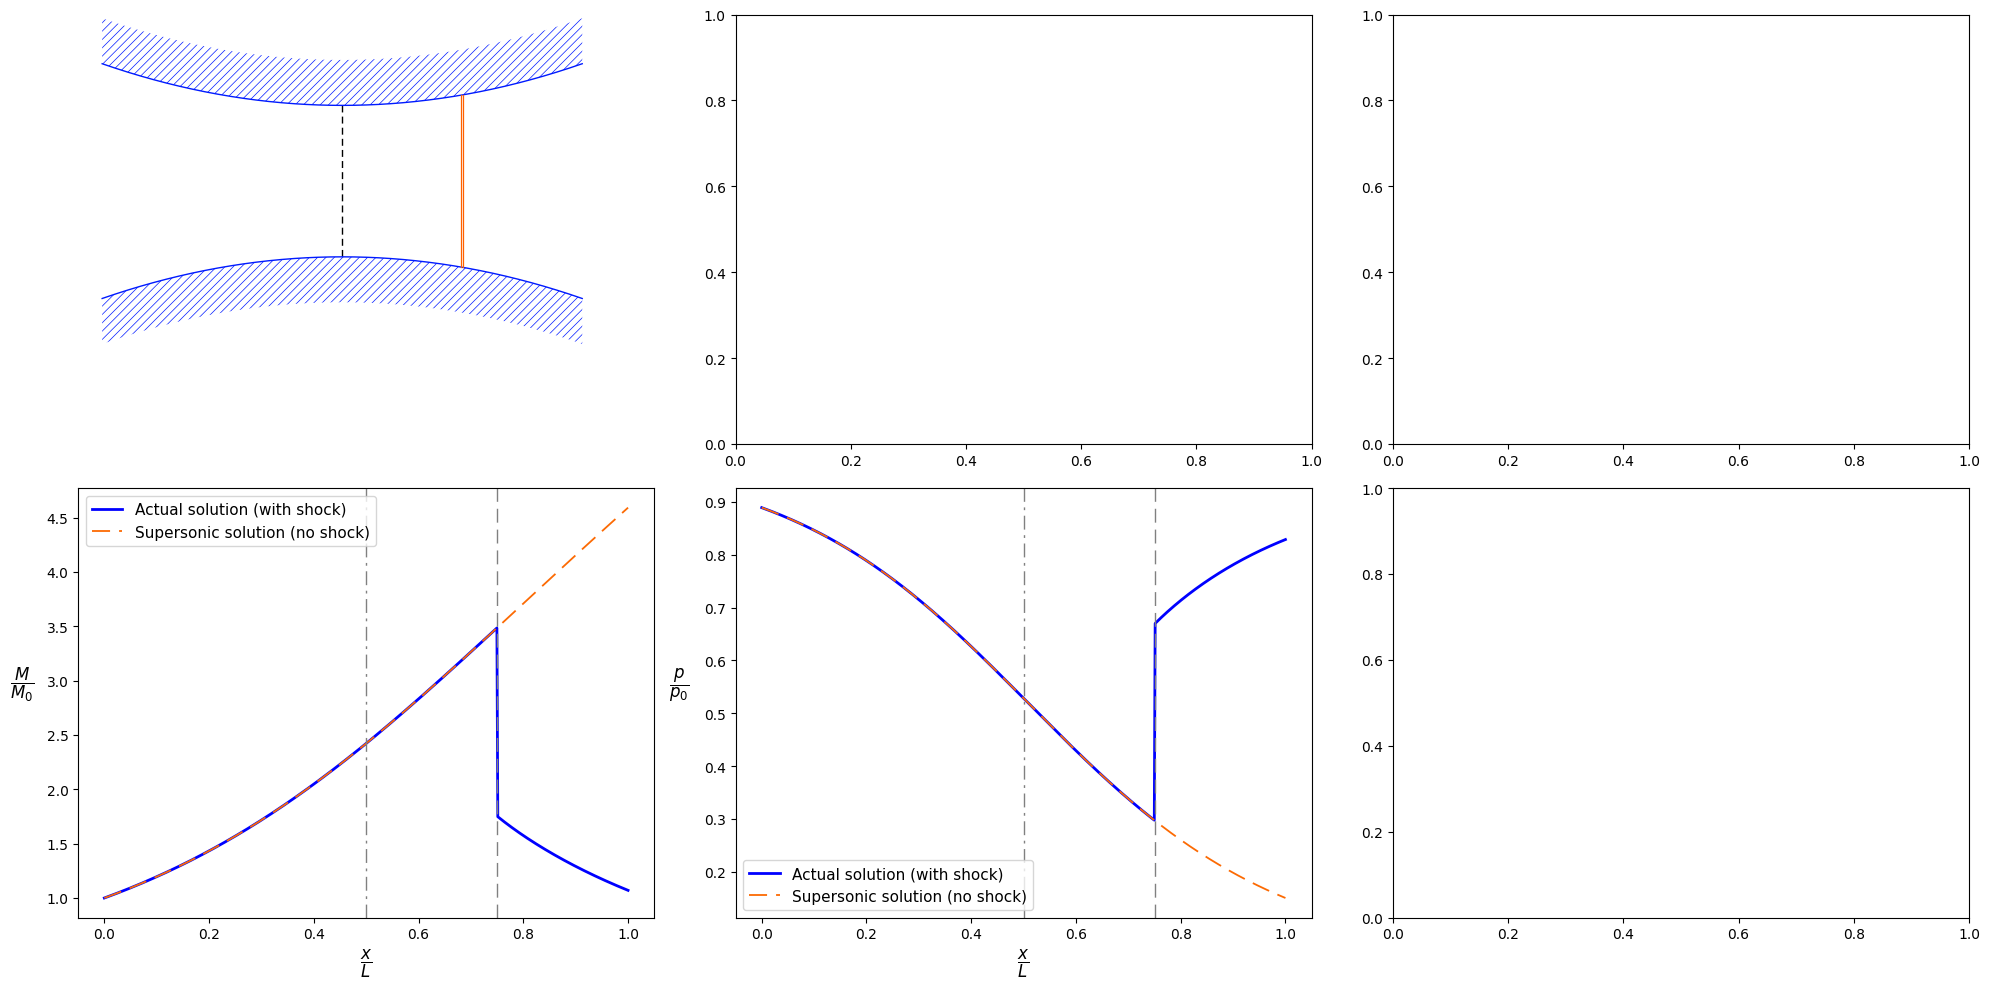

In [6]:
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Gas properties and nozzle geometry (edit these for your problem)
# ----------------------------------------------------------------------
gamma = 1.4  # ratio of specific heats (1.4 for air)

# Nozzle area distribution A(x)/A_throat, x in arbitrary length units.
# Given directly as A/A* = 1 + 2.2*(x - 0.5)^2  (throat at x = 0.5, length = 1)
x_min, x_throat, x_max = 0.0, 0.5, 1.0


def area_ratio(x):
    """A(x)/A_throat = 1 + 2.2*(x - 0.5)^2."""
    x = np.asarray(x, dtype=float)
    return 1.0 + 2.2 * (x - 0.5) ** 2

x_shock_target = 0.75
A_shock_ratio = area_ratio(np.array([x_shock_target]))[0]

# ----------------------------------------------------------------------
# 2. Isentropic relations
# ----------------------------------------------------------------------
def area_mach_relation(M, area_ratio_target, gamma=1.4):
    term = (2.0 / (gamma + 1.0)) * (1.0 + 0.5 * (gamma - 1.0) * M ** 2)
    AoA_star = (1.0 / M) * term ** ((gamma + 1.0) / (2.0 * (gamma - 1.0)))
    return AoA_star - area_ratio_target


def solve_mach_from_area(area_ratio_target, gamma=1.4, subsonic=True):
    if area_ratio_target <= 1.0 + 1e-12:
        return 1.0
    if subsonic:
        lo, hi = 1e-6, 1.0 - 1e-9
    else:
        lo, hi = 1.0 + 1e-9, 60.0
    return brentq(area_mach_relation, lo, hi, args=(area_ratio_target, gamma))


def T0_over_T(M, gamma=1.4):
    return 1.0 + 0.5 * (gamma - 1.0) * M ** 2


def p_over_p0_isentropic(M, gamma=1.4):
    return T0_over_T(M, gamma) ** (-gamma / (gamma - 1.0))


# ----------------------------------------------------------------------
# 3. Normal shock relations
# ----------------------------------------------------------------------
def normal_shock(M1, gamma=1.4):
    """Given upstream Mach M1 (>1), return M2, p2/p1, rho2/rho1, p02/p01."""
    M2 = np.sqrt(
        (1.0 + 0.5 * (gamma - 1.0) * M1 ** 2)
        / (gamma * M1 ** 2 - 0.5 * (gamma - 1.0))
    )
    p2_p1 = 1.0 + (2.0 * gamma / (gamma + 1.0)) * (M1 ** 2 - 1.0)
    rho2_rho1 = ((gamma + 1.0) * M1 ** 2) / ((gamma - 1.0) * M1 ** 2 + 2.0)
    p02_p01 = (rho2_rho1 ** (gamma / (gamma - 1.0))) * (
        (gamma + 1.0) / (2.0 * gamma * M1 ** 2 - (gamma - 1.0))
    ) ** (1.0 / (gamma - 1.0))
    return M2, p2_p1, rho2_rho1, p02_p01


# ----------------------------------------------------------------------
# 4. Build the solution along x
# ----------------------------------------------------------------------
n_points = 600
x = np.linspace(x_min, x_max, n_points)
A_ratio_x = area_ratio(x)

# Shock position (given directly above as x_shock_target)
x_shock = x_shock_target

M1_at_shock = solve_mach_from_area(A_shock_ratio, gamma, subsonic=False)
M2_at_shock, p2_p1, rho2_rho1, p02_p01 = normal_shock(M1_at_shock, gamma)

# Effective post-shock A* (mathematical reference area for the subsonic
# branch downstream of the shock): A_shock / A*_2 = (A/A*)_subsonic(M2)
AoAstar_2_at_shock = area_mach_relation(M2_at_shock, 0.0, gamma) + 0.0  # = (A/A*)(M2)
A_star2_over_Astar1 = A_shock_ratio / AoAstar_2_at_shock

M = np.zeros_like(x)
p_p0 = np.zeros_like(x)

for i, xi in enumerate(x):
    Ar = A_ratio_x[i]
    if xi <= x_throat:
        Mi = solve_mach_from_area(Ar, gamma, subsonic=True)
        p_p0[i] = p_over_p0_isentropic(Mi, gamma)
    elif xi <= x_shock:
        Mi = solve_mach_from_area(Ar, gamma, subsonic=False)
        p_p0[i] = p_over_p0_isentropic(Mi, gamma)
    else:
        Ar2 = Ar / A_star2_over_Astar1  # area ratio referenced to post-shock A*
        Mi = solve_mach_from_area(Ar2, gamma, subsonic=True)
        p_p0[i] = p_over_p0_isentropic(Mi, gamma) * p02_p01
    M[i] = Mi # type: ignore

M0_ref = M[0]  # inlet Mach number, used only to normalize the Mach curve
M_M0 = M / M0_ref

# ---- "would-be" Supersonic solution with NO shock (dashed curve,
#      matches the dashed continuation shown in the textbook figure) ----
M_noshock = np.zeros_like(x)
p_p0_noshock = np.zeros_like(x)
for i, xi in enumerate(x):
    if xi <= x_throat:
        M_noshock[i] = M[i]
        p_p0_noshock[i] = p_p0[i]
    else:
        Mi = solve_mach_from_area(A_ratio_x[i], gamma, subsonic=False)
        M_noshock[i] = Mi # type: ignore
        p_p0_noshock[i] = p_over_p0_isentropic(Mi, gamma)
M_M0_noshock = M_noshock / M0_ref

p_star_p0 = p_over_p0_isentropic(1.0, gamma)  # critical pressure ratio (0.528 for air)

# ----------------------------------------------------------------------
# 4.1. Compute the fig params
# ----------------------------------------------------------------------
# ---- parameters ----
A = 0.25  # scale factor for wall half-height, adjust to taste
half_height = A * (1 + 2.2 * (x - 0.5) ** 2)  # A*(1+2.2(x-0.5)^2)

y_top = half_height
y_bot = -half_height
wall_thickness = 0.15  # how far the hatched "solid wall" extends beyond the duct wall

# ---- colors ----
wall_fill = "white" # tangerine
wall_edge = "#001aff"
shock_color = "#ff6200"
axis_color = "black"

plt.rcParams["hatch.linewidth"] = 0.5
plt.rcParams['hatch.color'] = "#001aff"

# ----------------------------------------------------------------------
# 5. Plot
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
plt.subplots_adjust(wspace=1.1, hspace=1.1) 

# --- Nozzle profile panel (top-left) ---
ax = axes[0, 0]
# --- hatched wall regions (solid material) ---
ax.fill_between(
    x,
    y_top,
    y_top + wall_thickness,
    facecolor=wall_fill,
    edgecolor="#001aff",
    hatch="////",
    linewidth=0.0,
    zorder=2,
)
ax.fill_between(
    x,
    y_bot - wall_thickness,
    y_bot,
    facecolor=wall_fill,
    edgecolor="#001aff",
    hatch="////",
    linewidth=0.0,
    zorder=2,
)

# --- wall boundary lines ---
ax.plot(x, y_top, color=wall_edge, linewidth=1.0, zorder=3)
ax.plot(x, y_bot, color=wall_edge, linewidth=1.0, zorder=3)

# --- throat marker ---
throat_top = A * 1.0 + wall_thickness
throat_bot = -A * 1.0 - wall_thickness
axis_y = -(A * 1.55 + wall_thickness + 0.22)
ax.plot(
    [0.5, 0.5],
    [A, -A],
    color=axis_color,
    linestyle="--",
    linewidth=1.0,
    dashes=(5, 3),
    zorder=1,
)

# --- normal shock wave (two thin lines) ---
shock_half = A * (1 + 2.2 * (x_shock_target - 0.5) ** 2)
shock_dx = 0.0025
ax.plot(
    [x_shock_target - shock_dx, x_shock_target - shock_dx],
    [-shock_half, shock_half],
    color=shock_color,
    linewidth=0.9,
    zorder=4,
)
ax.plot(
    [x_shock_target + shock_dx, x_shock_target + shock_dx],
    [-shock_half, shock_half],
    color=shock_color,
    linewidth=0.9,
    zorder=4,
)

ax.set_xlim(-0.05, 1.15)
ax.set_ylim(axis_y - 0.11, throat_top + 0.15)
ax.axis("off")

# --- M/M0 panel (bottom-left), styled like the textbook figure ---
ax = axes[1, 0]
ax.plot(x, M_M0, lw=2, color="blue", label="Actual solution (with shock)")
ax.plot(x, M_M0_noshock, lw=1.3, color="#fc6a03", ls="--",
        label="Supersonic solution (no shock)", dashes=(10, 5))
ax.axvline(x_throat, color="gray", lw=1, linestyle=(0, (10, 4, 2, 4)))
ax.axvline(x_shock, color="gray", ls="--", lw=1, dashes=(10, 5))
ax.set_xlabel(r"$\dfrac{x}{L}$", fontsize=12)
ax.set_ylabel(r"$\dfrac{M}{M_0}$", fontsize=12, rotation='horizontal', labelpad=17.5)
ax.legend(fontsize=11)

# --- p/p0 panel (bottom-middle) ---
ax = axes[1, 1]
ax.plot(x, p_p0, lw=2, color="blue", label="Actual solution (with shock)")
ax.plot(x, p_p0_noshock, lw=1.3, color="#fc6a03", ls="--",
        label="Supersonic solution (no shock)", dashes=(10, 5))
ax.axvline(x_throat, color="gray", lw=1, linestyle=(0, (10, 4, 2, 4)))
ax.axvline(x_shock, color="gray", ls="--", lw=1, dashes=(10, 5))
ax.set_xlabel(r"$\dfrac{x}{L}$", fontsize=12)
ax.set_ylabel(r"$\dfrac{p}{p_0}$", fontsize=12, rotation='horizontal', labelpad=17.5)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("./nozzle_properties.svg", format="svg", transparent=True)
